47 checkpoints loaded


original shape: (20, 32, 32, 3)
shifted shape:  (20, 32, 32, 3)


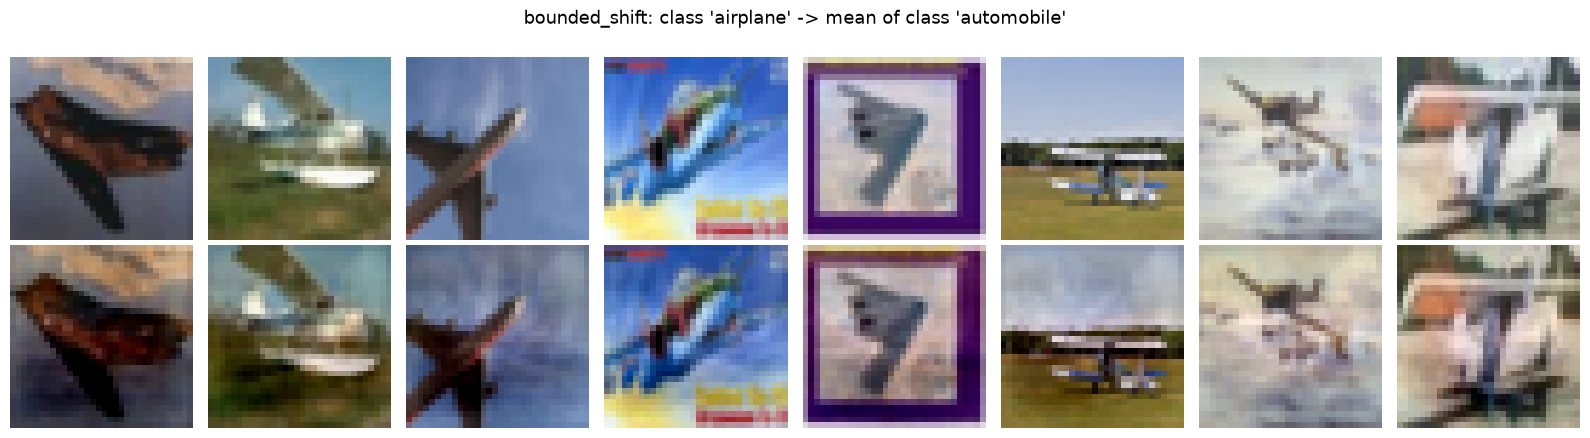

In [2]:
CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                    "dog", "frog", "horse", "ship", "truck"]

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4.5))

for i in range(n_show):
    axes[0, i].imshow(np.clip(original[i], 0, 1))
    axes[0, i].axis("off")

    axes[1, i].imshow(np.clip(shifted[i], 0, 1))
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Shifted", fontsize=12)

fig.suptitle(
    f"bounded_shift: class '{CIFAR10_CLASSES[source_class]}' "
    f"-> mean of class '{CIFAR10_CLASSES[target_class]}'",
    fontsize=13
)
fig.tight_layout()
#plt.savefig("/home/nakano/cuda_test/bounded_shift_visualization.pdf", bbox_inches="tight")
plt.show()

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Acc/Loss評価結果(bounded_shift, target_labelとしての精度)
EVAL_PATH = Path("/home/nakano/cuda_test/eval_results/bounded_shift_full.json")
with open(EVAL_PATH) as f:
    eval_data = json.load(f)

eval_steps      = [r["step"] for r in eval_data["results"]]
eval_loss       = [r["loss"] for r in eval_data["results"]]
eval_acc        = [r["accuracy"] for r in eval_data["results"]]

# 通常のCIFAR10テストデータでの評価結果(以前計算済みのdsb_eval_results.json)
CIFAR_TEST_PATH = Path("/home/nakano/cuda_test/dsb_eval_results.json")
with open(CIFAR_TEST_PATH) as f:
    cifar_eval = json.load(f)

test_steps = [r["step"] for r in cifar_eval]
test_train_acc  = [r["train_acc"] for r in cifar_eval]
test_train_loss = [r["train_loss"] for r in cifar_eval]
test_test_acc   = [r["test_acc"] for r in cifar_eval]
test_test_loss  = [r["test_loss"] for r in cifar_eval]

print(f"bounded_shift eval points: {len(eval_steps)}")
print(f"cifar10 train/test eval points: {len(test_steps)}")

bounded_shift eval points: 47
cifar10 train/test eval points: 47


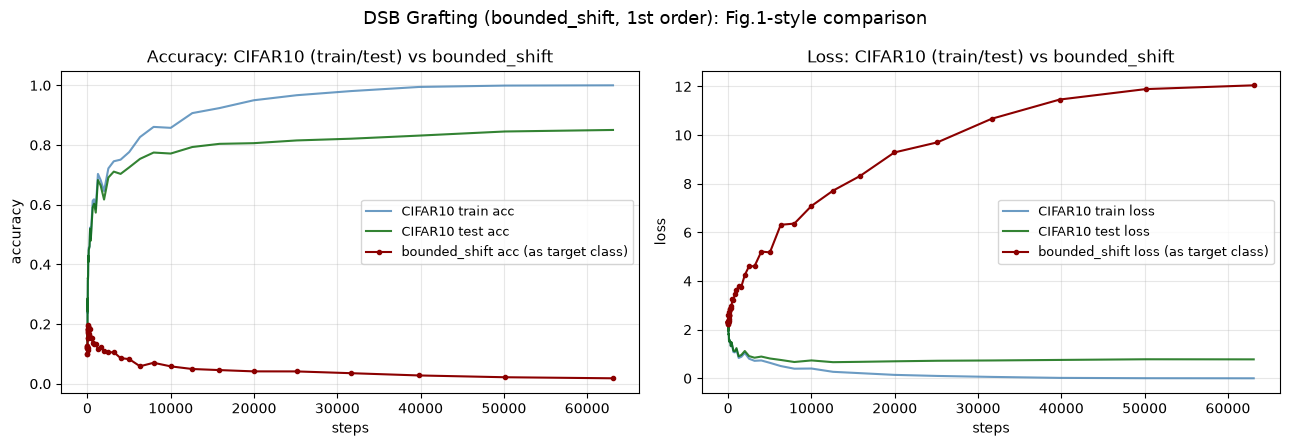

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Accuracy ---
ax = axes[0]
ax.plot(test_steps, test_train_acc, color="steelblue", label="CIFAR10 train acc", alpha=0.8)
ax.plot(test_steps, test_test_acc,  color="darkgreen", label="CIFAR10 test acc", alpha=0.8)
ax.plot(eval_steps, eval_acc, color="darkred", marker="o", markersize=3,
        label="bounded_shift acc (as target class)")
ax.set_xlabel("steps")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy: CIFAR10 (train/test) vs bounded_shift")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Loss ---
ax = axes[1]
ax.plot(test_steps, test_train_loss, color="steelblue", label="CIFAR10 train loss", alpha=0.8)
ax.plot(test_steps, test_test_loss,  color="darkgreen", label="CIFAR10 test loss", alpha=0.8)
ax.plot(eval_steps, eval_loss, color="darkred", marker="o", markersize=3,
        label="bounded_shift loss (as target class)")
ax.set_xlabel("steps")
ax.set_ylabel("loss")
ax.set_title("Loss: CIFAR10 (train/test) vs bounded_shift")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle("DSB Grafting (bounded_shift, 1st order): Fig.1-style comparison", fontsize=13)
fig.tight_layout()
#plt.savefig("/home/nakano/cuda_test/eval_results/bounded_shift_vs_cifar10.pdf", bbox_inches="tight")
plt.show()

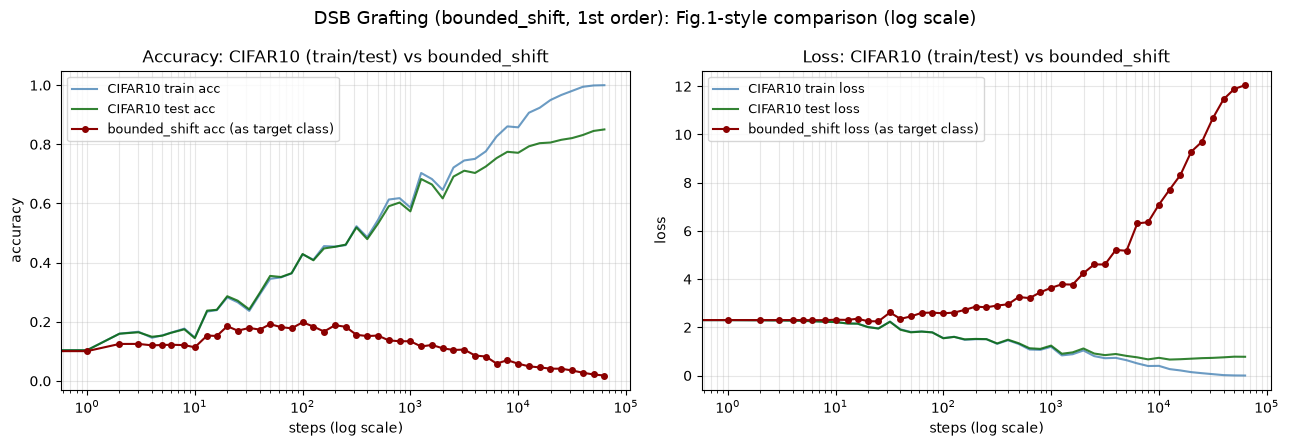

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Accuracy ---
ax = axes[0]
ax.plot(test_steps, test_train_acc, color="steelblue", label="CIFAR10 train acc", alpha=0.8)
ax.plot(test_steps, test_test_acc,  color="darkgreen", label="CIFAR10 test acc", alpha=0.8)
ax.plot(eval_steps, eval_acc, color="darkred", marker="o", markersize=4,
        label="bounded_shift acc (as target class)")
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy: CIFAR10 (train/test) vs bounded_shift")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# --- Loss ---
ax = axes[1]
ax.plot(test_steps, test_train_loss, color="steelblue", label="CIFAR10 train loss", alpha=0.8)
ax.plot(test_steps, test_test_loss,  color="darkgreen", label="CIFAR10 test loss", alpha=0.8)
ax.plot(eval_steps, eval_loss, color="darkred", marker="o", markersize=4,
        label="bounded_shift loss (as target class)")
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("loss")
ax.set_title("Loss: CIFAR10 (train/test) vs bounded_shift")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB Grafting (bounded_shift, 1st order): Fig.1-style comparison (log scale)", fontsize=13)
fig.tight_layout()
#plt.savefig("/home/nakano/cuda_test/eval_results/bounded_shift_vs_cifar10_log.pdf", bbox_inches="tight")
plt.show()

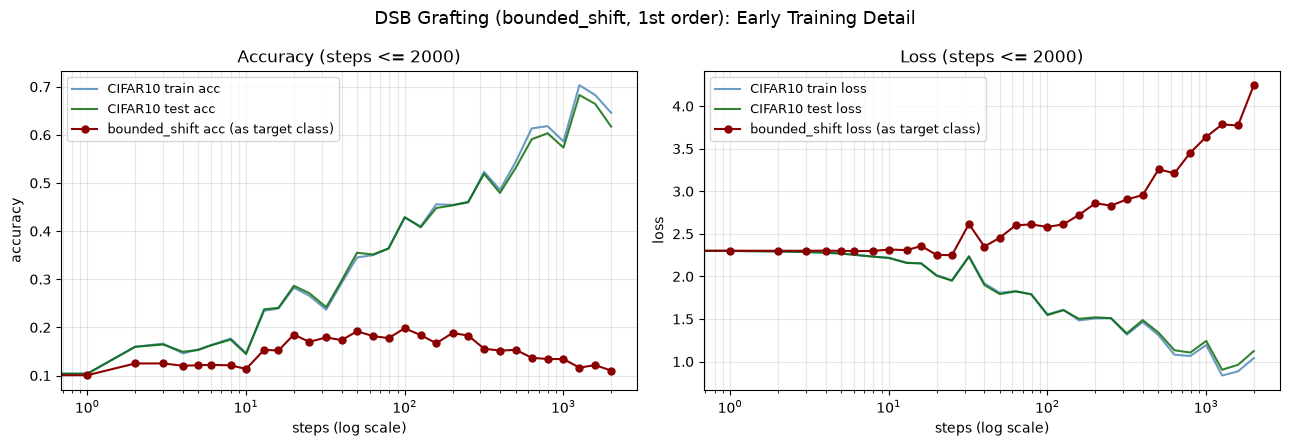

In [6]:
STEP_LIMIT = 2000

def filter_steps(steps, *arrays):
    steps = np.array(steps)
    mask = steps <= STEP_LIMIT
    return (steps[mask],) + tuple(np.array(a)[mask] for a in arrays)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Accuracy (序盤のみ) ---
ax = axes[0]
s, ta, va = filter_steps(test_steps, test_train_acc, test_test_acc)
ax.plot(s, ta, color="steelblue", label="CIFAR10 train acc", alpha=0.8)
ax.plot(s, va, color="darkgreen", label="CIFAR10 test acc", alpha=0.8)
s2, ea = filter_steps(eval_steps, eval_acc)
ax.plot(s2, ea, color="darkred", marker="o", markersize=5,
        label="bounded_shift acc (as target class)")
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("accuracy")
ax.set_title(f"Accuracy (steps <= {STEP_LIMIT})")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# --- Loss (序盤のみ) ---
ax = axes[1]
s, tl, vl = filter_steps(test_steps, test_train_loss, test_test_loss)
ax.plot(s, tl, color="steelblue", label="CIFAR10 train loss", alpha=0.8)
ax.plot(s, vl, color="darkgreen", label="CIFAR10 test loss", alpha=0.8)
s2, el = filter_steps(eval_steps, eval_loss)
ax.plot(s2, el, color="darkred", marker="o", markersize=5,
        label="bounded_shift loss (as target class)")
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("loss")
ax.set_title(f"Loss (steps <= {STEP_LIMIT})")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB Grafting (bounded_shift, 1st order): Early Training Detail", fontsize=13)
fig.tight_layout()
#plt.savefig("/home/nakano/cuda_test/eval_results/bounded_shift_vs_cifar10_early.pdf", bbox_inches="tight")
plt.show()

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")

# --- 通常CIFAR10のtrain/test ---
with open(RESULTS_DIR / "dsb_eval_results.json") as f:
    cifar_eval = json.load(f)

cifar_steps      = [r["step"] for r in cifar_eval]
cifar_train_loss = [r["train_loss"] for r in cifar_eval]
cifar_train_acc  = [r["train_acc"] for r in cifar_eval]
cifar_test_loss  = [r["test_loss"] for r in cifar_eval]
cifar_test_acc   = [r["test_acc"] for r in cifar_eval]

# --- Grafting 3手法 ---
def load_eval_results(name):
    with open(RESULTS_DIR / "eval_results" / f"{name}.json") as f:
        return json.load(f)

moment_curves = {
    "bounded_shift": load_eval_results("bounded_shift_full"),
    "cqn": load_eval_results("cqn_full"),
    "gaussian_ot": load_eval_results("gaussian_ot_full"),
}

colors = {"bounded_shift": "darkred", "cqn": "darkorange", "gaussian_ot": "darkviolet"}

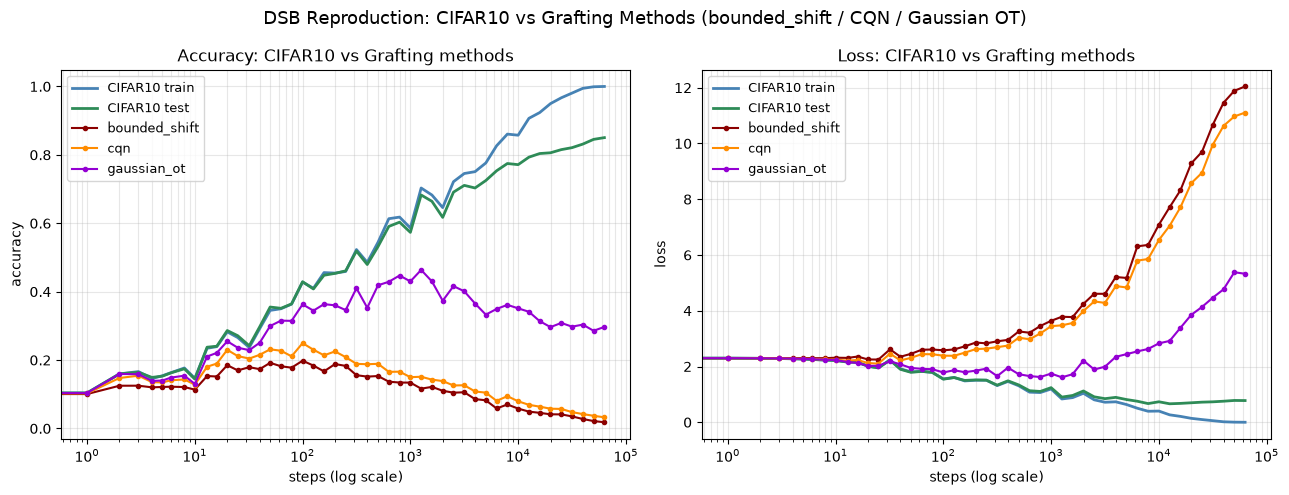

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Accuracy ---
ax = axes[0]
ax.plot(cifar_steps, cifar_train_acc, color="steelblue", linewidth=2, label="CIFAR10 train")
ax.plot(cifar_steps, cifar_test_acc,  color="seagreen",  linewidth=2, label="CIFAR10 test")
for name, data in moment_curves.items():
    steps = [r["step"] for r in data["results"]]
    accs  = [r["accuracy"] for r in data["results"]]
    ax.plot(steps, accs, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy: CIFAR10 vs Grafting methods")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# --- Loss ---
ax = axes[1]
ax.plot(cifar_steps, cifar_train_loss, color="steelblue", linewidth=2, label="CIFAR10 train")
ax.plot(cifar_steps, cifar_test_loss,  color="seagreen",  linewidth=2, label="CIFAR10 test")
for name, data in moment_curves.items():
    steps = [r["step"] for r in data["results"]]
    losses = [r["loss"] for r in data["results"]]
    ax.plot(steps, losses, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("loss")
ax.set_title("Loss: CIFAR10 vs Grafting methods")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB Reproduction: CIFAR10 vs Grafting Methods (bounded_shift / CQN / Gaussian OT)", fontsize=13)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "grafting_full_comparison.pdf", bbox_inches="tight")
plt.show()

NameError: name 'llc_curves' is not defined

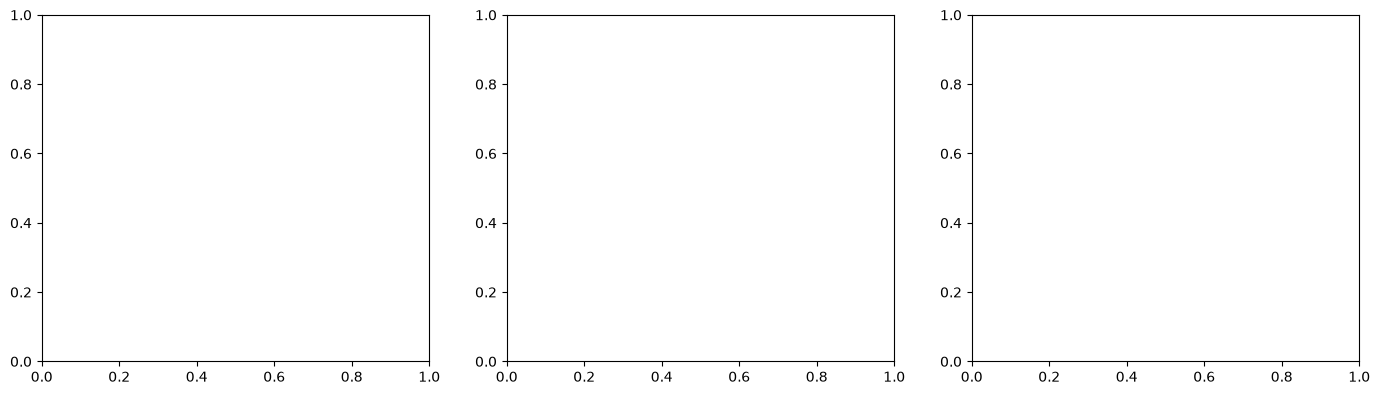

In [9]:
# --- 描画 ---
colors = {"bounded_shift": "darkred", "cqn": "darkorange", "gaussian_ot": "darkviolet"}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (1) LLC
ax = axes[0]
for name, (steps, lambdahats) in llc_curves.items():
    steps = np.array(steps)
    lambdahats = np.array(lambdahats)
    mask = ~np.isnan(lambdahats)
    ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=3,
            color=colors[name], label=name)
ax.set_xlabel("steps")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_title("LLC comparison (Grafting methods)")
ax.legend()
ax.grid(alpha=0.3)

# (2) Accuracy
ax = axes[1]
for name, (steps, losses, accs) in eval_curves.items():
    ax.plot(steps, accs, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xlabel("steps")
ax.set_ylabel("accuracy (as target class)")
ax.set_title("Accuracy comparison")
ax.legend()
ax.grid(alpha=0.3)

# (3) Loss
ax = axes[2]
for name, (steps, losses, accs) in eval_curves.items():
    ax.plot(steps, losses, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xlabel("steps")
ax.set_ylabel("loss (as target class)")
ax.set_title("Loss comparison")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle("DSB Grafting Methods Comparison (bounded_shift / CQN / Gaussian OT)", fontsize=13)
fig.tight_layout()
#plt.savefig(RESULTS_DIR / "grafting_comparison.pdf", bbox_inches="tight")
plt.show()

KeyError: 'conrad'

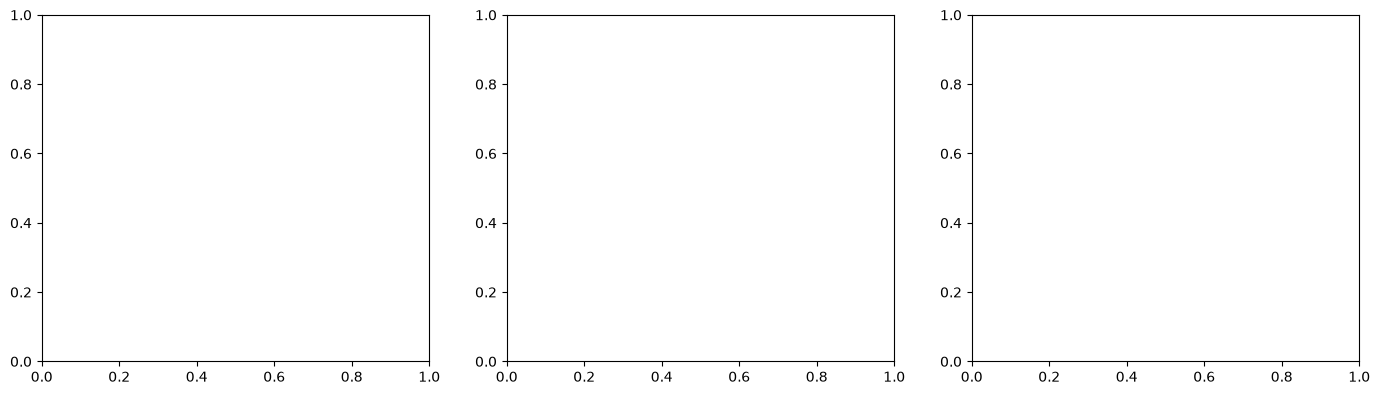

In [ ]:
STEP_LIMIT = 2000

def filter_by_step(steps, values, limit):
    steps = np.array(steps)
    values = np.array(values)
    mask = (steps <= limit) & (steps >= 1)  # log軸なのでstep=0は除外
    return steps[mask], values[mask]


fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (1) LLC (序盤・対数軸)
ax = axes[0]
for name, (steps, lambdahats) in llc_curves.items():
    lambdahats = np.array(lambdahats)
    s, v = filter_by_step(steps, lambdahats, STEP_LIMIT)
    valid = ~np.isnan(v)
    ax.plot(s[valid], v[valid], marker="o", markersize=4,
            color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_title(f"LLC (steps <= {STEP_LIMIT})")
ax.legend()
ax.grid(alpha=0.3, which="both")

# (2) Accuracy (序盤・対数軸)
ax = axes[1]
for name, (steps, losses, accs) in eval_curves.items():
    s, v = filter_by_step(steps, accs, STEP_LIMIT)
    ax.plot(s, v, marker="o", markersize=4, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("accuracy (as target class)")
ax.set_title(f"Accuracy (steps <= {STEP_LIMIT})")
ax.legend()
ax.grid(alpha=0.3, which="both")

# (3) Loss (序盤・対数軸)
ax = axes[2]
for name, (steps, losses, accs) in eval_curves.items():
    s, v = filter_by_step(steps, losses, STEP_LIMIT)
    ax.plot(s, v, marker="o", markersize=4, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("loss (as target class)")
ax.set_title(f"Loss (steps <= {STEP_LIMIT})")
ax.legend()
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB Grafting Methods: Early Training Detail (log scale)", fontsize=13)
fig.tight_layout()
#plt.savefig(RESULTS_DIR / "grafting_comparison_early_log.pdf", bbox_inches="tight")
plt.show()

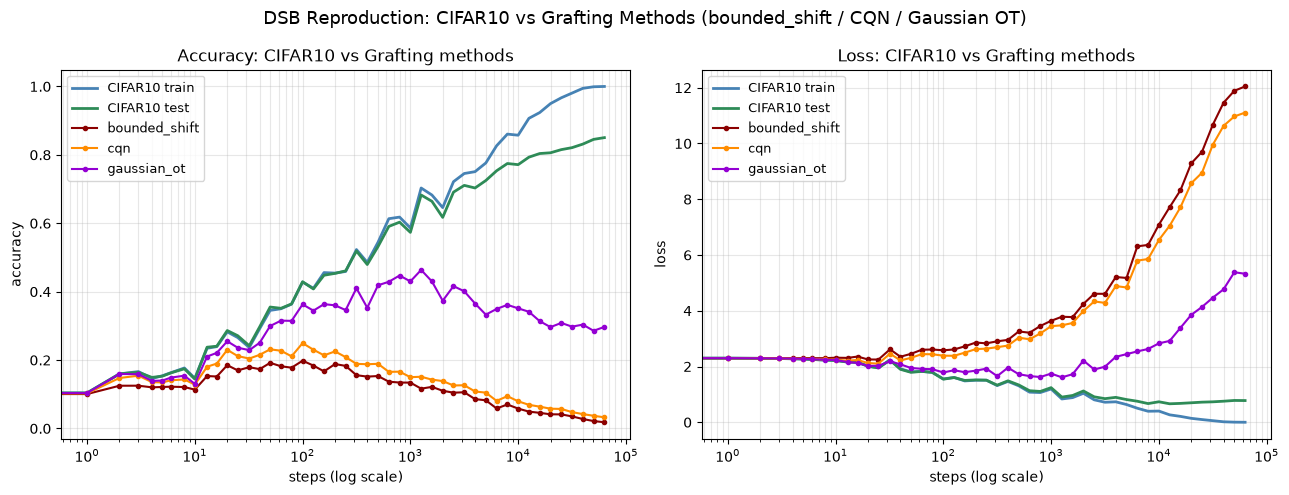

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Accuracy ---
ax = axes[0]
ax.plot(cifar_steps, cifar_train_acc, color="steelblue", linewidth=2, label="CIFAR10 train")
ax.plot(cifar_steps, cifar_test_acc,  color="seagreen",  linewidth=2, label="CIFAR10 test")
for name, data in moment_curves.items():
    steps = [r["step"] for r in data["results"]]
    accs  = [r["accuracy"] for r in data["results"]]
    ax.plot(steps, accs, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy: CIFAR10 vs Grafting methods")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# --- Loss ---
ax = axes[1]
ax.plot(cifar_steps, cifar_train_loss, color="steelblue", linewidth=2, label="CIFAR10 train")
ax.plot(cifar_steps, cifar_test_loss,  color="seagreen",  linewidth=2, label="CIFAR10 test")
for name, data in moment_curves.items():
    steps = [r["step"] for r in data["results"]]
    losses = [r["loss"] for r in data["results"]]
    ax.plot(steps, losses, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("loss")
ax.set_title("Loss: CIFAR10 vs Grafting methods")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")


fig.suptitle("DSB Reproduction: CIFAR10 vs Grafting Methods (bounded_shift / CQN / Gaussian OT)", fontsize=13)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "grafting_full_comparison.pdf", bbox_inches="tight")
plt.show()

# LLCの結果

cifar10_train_llc_full.json loaded
Loaded LLC curves:
  bounded_shift: 47 points
  cqn: 46 points
  gaussian_ot: 46 points
  cifar10_train: 46 points


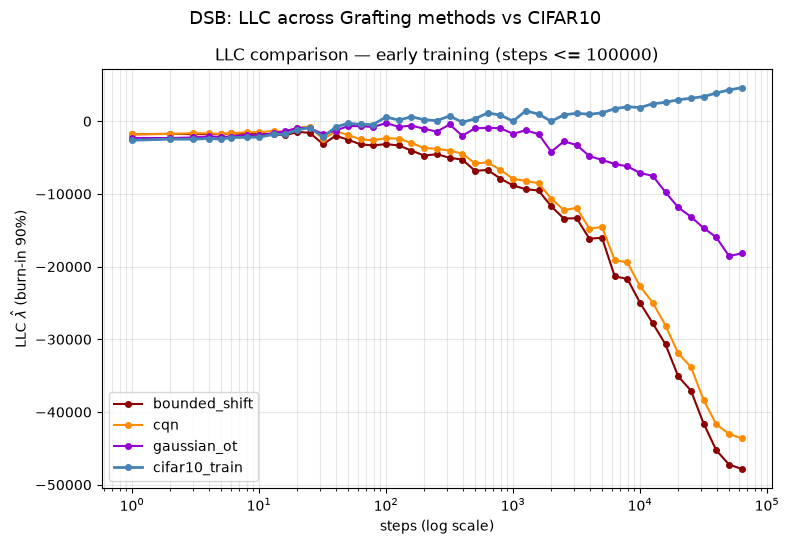

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")

# --- LLC結果の読み込み ---
def load_llc_results(name):
    with open(RESULTS_DIR / "llc_results" / f"{name}.json") as f:
        return json.load(f)

def compute_lambdahat(rec, n, burn_in_ratio=0.9):
    trace = np.array(rec["loss_trace"])
    init_loss = rec["init_loss"]
    itemp = 1 / np.log(n)
    burn_in = int(len(trace) * burn_in_ratio)
    valid = trace[burn_in:]
    valid = valid[~np.isnan(valid) & ~np.isinf(valid)]
    if len(valid) == 0:
        return np.nan
    return (np.mean(valid) - init_loss) * n * itemp

methods = {
    "bounded_shift": load_llc_results("bounded_shift_llc_full"),
    "cqn": load_llc_results("cqn_llc_full"),
    "gaussian_ot": load_llc_results("gaussian_ot_llc_full"),
}

# CIFAR10通常データのLLCがあれば追加
try:
    methods["cifar10_train"] = load_llc_results("cifar10_train_llc_full")
    print("cifar10_train_llc_full.json loaded")
except FileNotFoundError:
    print("cifar10_train_llc_full.json not found yet, skipping")

colors = {
    "bounded_shift": "darkred",
    "cqn": "darkorange",
    "gaussian_ot": "darkviolet",
    "cifar10_train": "steelblue",
}

llc_curves = {}
for name, data in methods.items():
    n = data["n_llc_samples_actual"]
    steps = [r["step"] for r in data["results"]]
    lambdahats = [compute_lambdahat(r, n, burn_in_ratio=0.9) for r in data["results"]]
    llc_curves[name] = (np.array(steps), np.array(lambdahats))

print("Loaded LLC curves:")
for name, (steps, _) in llc_curves.items():
    print(f"  {name}: {len(steps)} points")
    
    
    
STEP_LIMIT = 100000

fig, ax = plt.subplots(figsize=(8, 5.5))

for name, (steps, lambdahats) in llc_curves.items():
    mask = (steps <= STEP_LIMIT) & (steps >= 1) & ~np.isnan(lambdahats)
    ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=4,
            color=colors[name], label=name,
            linewidth=2 if name == "cifar10_train" else 1.5)

ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_title(f"LLC comparison — early training (steps <= {STEP_LIMIT})")
ax.legend()
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB: LLC across Grafting methods vs CIFAR10", fontsize=13)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "llc_early_log_comparison.pdf", bbox_inches="tight")
plt.show()

### 0以上で可視化

bounded_shift: no positive values in range
cqn: no positive values in range
gaussian_ot: no positive values in range


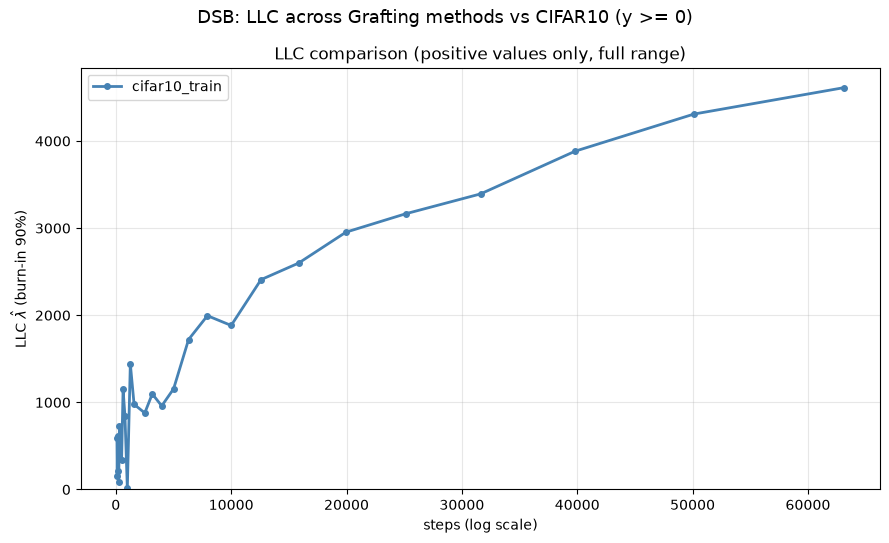

In [ ]:
STEP_LIMIT = 1000000  # 実質全範囲

fig, ax = plt.subplots(figsize=(9, 5.5))

for name, (steps, lambdahats) in llc_curves.items():
    mask = (steps <= STEP_LIMIT) & (steps >= 1) & ~np.isnan(lambdahats) & (lambdahats >= 0)
    if mask.sum() == 0:
        print(f"{name}: no positive values in range")
        continue
    ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=4,
            color=colors[name], label=name,
            linewidth=2 if name == "cifar10_train" else 1.5)

#ax.set_xscale("log")
ax.set_ylim(bottom=0)
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_title("LLC comparison (positive values only, full range)")
ax.legend()
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB: LLC across Grafting methods vs CIFAR10 (y >= 0)", fontsize=13)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "llc_full_log_comparison_positive.pdf", bbox_inches="tight")
plt.show()

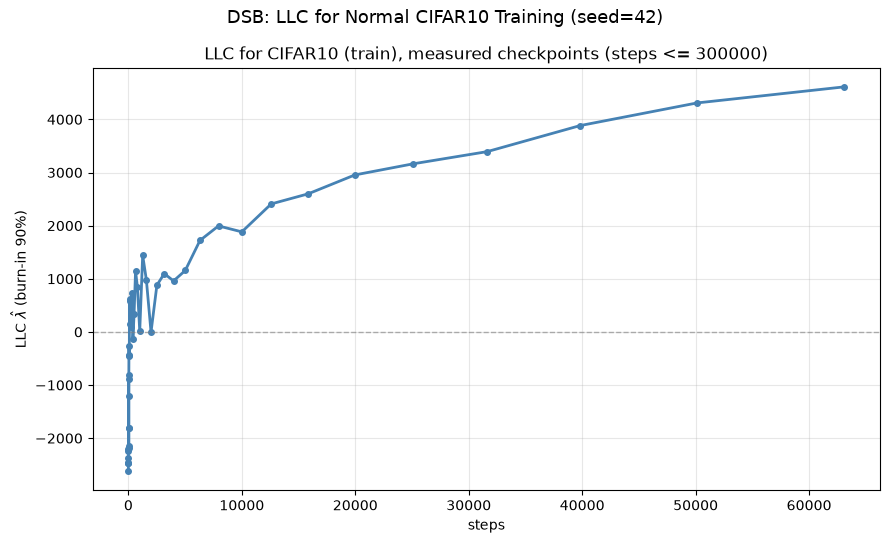

In [ ]:
STEP_LIMIT = 300000  # 例: 2000 のように指定すると打ち切れる。Noneなら全範囲。

fig, ax = plt.subplots(figsize=(9, 5.5))

steps, lambdahats = llc_curves["cifar10_train"]
mask = ~np.isnan(lambdahats)
if STEP_LIMIT is not None:
    mask &= (steps <= STEP_LIMIT)

ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=4,
        color=colors["cifar10_train"], linewidth=2)

ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("steps")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
title_suffix = f" (steps <= {STEP_LIMIT})" if STEP_LIMIT is not None else " (all steps)"
ax.set_title(f"LLC for CIFAR10 (train), measured checkpoints{title_suffix}")
ax.grid(alpha=0.3)

fig.suptitle("DSB: LLC for Normal CIFAR10 Training (seed=42)", fontsize=13)
fig.tight_layout()

suffix = f"_upto{STEP_LIMIT}" if STEP_LIMIT is not None else "_full"
plt.savefig(RESULTS_DIR / f"llc_cifar10_train_linear{suffix}.pdf", bbox_inches="tight")
plt.show()

# Deletion 描画

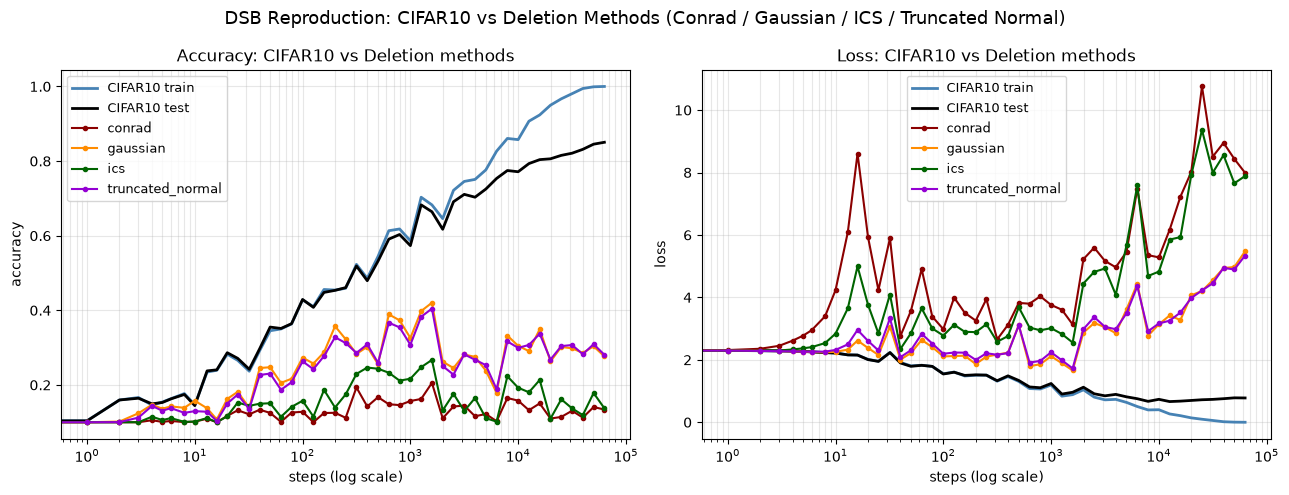

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")

# --- 通常CIFAR10のtrain/test ---
with open(RESULTS_DIR / "dsb_eval_results.json") as f:
    cifar_eval = json.load(f)

cifar_steps      = [r["step"] for r in cifar_eval]
cifar_train_loss = [r["train_loss"] for r in cifar_eval]
cifar_train_acc  = [r["train_acc"] for r in cifar_eval]
cifar_test_loss  = [r["test_loss"] for r in cifar_eval]
cifar_test_acc   = [r["test_acc"] for r in cifar_eval]

# --- Deletion 4手法 ---
def load_eval_results(name):
    with open(RESULTS_DIR / "eval_results" / f"{name}.json") as f:
        return json.load(f)

deletion_curves = {
    "conrad": load_eval_results("conrad_full"),
    "gaussian": load_eval_results("gaussian_full"),
    "ics": load_eval_results("ics_full"),
    "truncated_normal": load_eval_results("truncated_normal_full"),
}

colors = {
    "conrad": "darkred",
    "gaussian": "darkorange",
    "ics": "darkgreen",
    "truncated_normal": "darkviolet",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Accuracy ---
ax = axes[0]
ax.plot(cifar_steps, cifar_train_acc, color="steelblue", linewidth=2, label="CIFAR10 train")
ax.plot(cifar_steps, cifar_test_acc,  color="black",  linewidth=2, label="CIFAR10 test")
for name, data in deletion_curves.items():
    steps = [r["step"] for r in data["results"]]
    accs  = [r["accuracy"] for r in data["results"]]
    ax.plot(steps, accs, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy: CIFAR10 vs Deletion methods")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# --- Loss ---
ax = axes[1]
ax.plot(cifar_steps, cifar_train_loss, color="steelblue", linewidth=2, label="CIFAR10 train")
ax.plot(cifar_steps, cifar_test_loss,  color="black",  linewidth=2, label="CIFAR10 test")
for name, data in deletion_curves.items():
    steps = [r["step"] for r in data["results"]]
    losses = [r["loss"] for r in data["results"]]
    ax.plot(steps, losses, marker="o", markersize=3, color=colors[name], label=name)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel("loss")
ax.set_title("Loss: CIFAR10 vs Deletion methods")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB Reproduction: CIFAR10 vs Deletion Methods (Conrad / Gaussian / ICS / Truncated Normal)", fontsize=13)
fig.tight_layout()
# plt.savefig(RESULTS_DIR / "deletion_full_comparison.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")

def load_llc_results(name):
    with open(RESULTS_DIR / "llc_results" / f"{name}.json") as f:
        return json.load(f)

def compute_lambdahat(rec, n, burn_in_ratio=0.9):
    trace = np.array(rec["loss_trace"])
    init_loss = rec["init_loss"]
    itemp = 1 / np.log(n)
    burn_in = int(len(trace) * burn_in_ratio)
    valid = trace[burn_in:]
    valid = valid[~np.isnan(valid) & ~np.isinf(valid)]
    if len(valid) == 0:
        return np.nan
    return (np.mean(valid) - init_loss) * n * itemp

methods = {
    "conrad": load_llc_results("conrad_llc_full"),
    "gaussian": load_llc_results("gaussian_llc_full"),
    "ics": load_llc_results("ics_llc_full"),
    "truncated_normal": load_llc_results("truncated_normal_llc_full"),
    "cifar10_train": load_llc_results("cifar10_train_llc_full"),
}

colors = {
    "conrad": "darkred",
    "gaussian": "darkorange",
    "ics": "darkgreen",
    "truncated_normal": "darkviolet",
    "cifar10_train": "steelblue",
}

llc_curves = {}
for name, data in methods.items():
    n = data["n_llc_samples_actual"]
    steps = [r["step"] for r in data["results"]]
    lambdahats = [compute_lambdahat(r, n, burn_in_ratio=0.9) for r in data["results"]]
    llc_curves[name] = (np.array(steps), np.array(lambdahats))

print("Loaded LLC curves:")
for name, (steps, _) in llc_curves.items():
    print(f"  {name}: {len(steps)} points")

Loaded LLC curves:
  conrad: 46 points
  gaussian: 46 points
  ics: 46 points
  truncated_normal: 46 points
  cifar10_train: 46 points


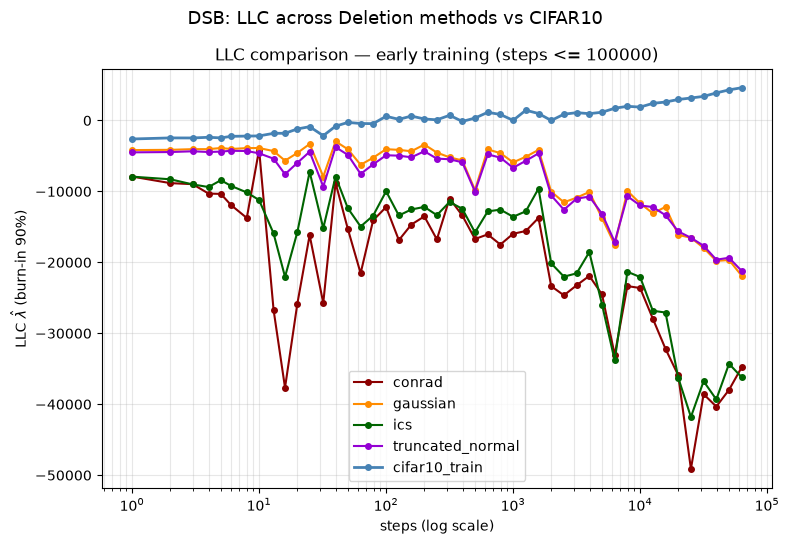

In [ ]:
STEP_LIMIT = 100000

fig, ax = plt.subplots(figsize=(8, 5.5))

for name, (steps, lambdahats) in llc_curves.items():
    mask = (steps <= STEP_LIMIT) & (steps >= 1) & ~np.isnan(lambdahats)
    ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=4,
            color=colors[name], label=name,
            linewidth=2 if name == "cifar10_train" else 1.5)

ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_title(f"LLC comparison — early training (steps <= {STEP_LIMIT})")
ax.legend()
ax.grid(alpha=0.3, which="both")

fig.suptitle("DSB: LLC across Deletion methods vs CIFAR10", fontsize=13)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "llc_deletion_early_log_comparison.pdf", bbox_inches="tight")
plt.show()

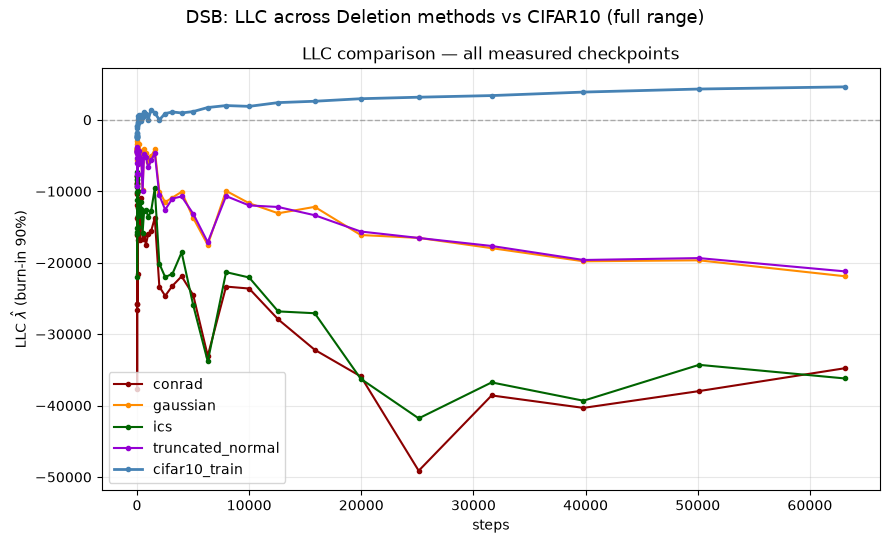

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for name, (steps, lambdahats) in llc_curves.items():
    mask = ~np.isnan(lambdahats)
    ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=3,
            color=colors[name], label=name,
            linewidth=2 if name == "cifar10_train" else 1.5)

ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("steps")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_title("LLC comparison — all measured checkpoints")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle("DSB: LLC across Deletion methods vs CIFAR10 (full range)", fontsize=13)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "llc_deletion_full_comparison.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import json
from pathlib import Path
import pandas as pd

results_base = Path("results/nakkiran_binary_training")
run_dirs = [p for p in results_base.iterdir() if p.is_dir() and p.name.isdigit()]
latest_run = max(run_dirs, key=lambda p: int(p.name))
print(f"Loading: {latest_run}")

with open(latest_run / "info.json") as f:
    info = json.load(f)

df = pd.DataFrame(info).sort_values("step").reset_index(drop=True)
print(f"{len(df)} records loaded (step 0 -> {df['step'].max()})")
df.head()

Loading: results/nakkiran_binary_training/1
41 records loaded (step 0 -> 20000)


,step,test_acc,train_acc,train_loss
0,0,0.5000,0.50000,NaN
1,500,0.6824,0.69128,0.662065
2,1000,0.7179,0.72812,0.583704
3,1500,0.7244,0.73030,0.543555
4,2000,0.7431,0.75134,0.502908


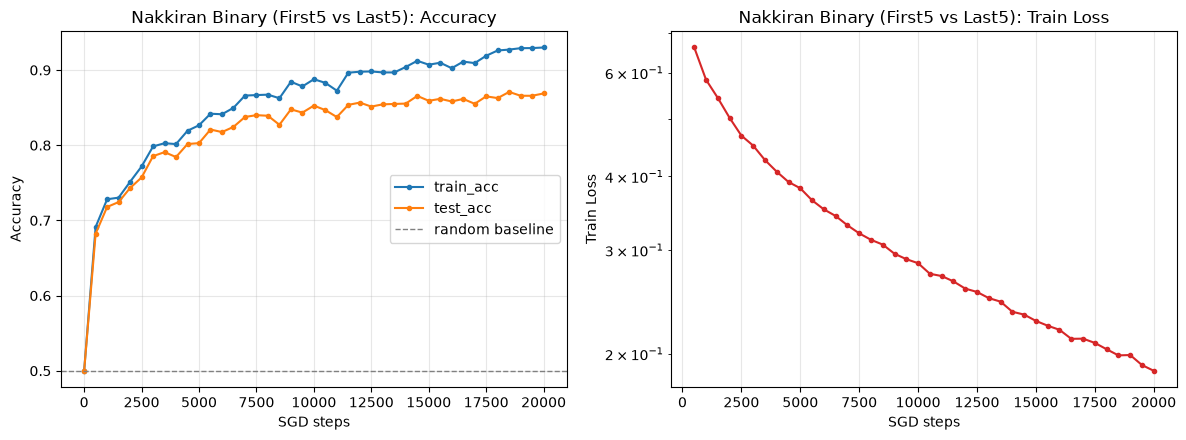

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 左: accuracy
axes[0].plot(df["step"], df["train_acc"], label="train_acc", marker="o", markersize=3)
axes[0].plot(df["step"], df["test_acc"], label="test_acc", marker="o", markersize=3)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random baseline")
axes[0].set_xlabel("SGD steps")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Nakkiran Binary (First5 vs Last5): Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 右: train loss (step=0 は train_loss=None なので除外)
df_loss = df.dropna(subset=["train_loss"])
axes[1].plot(df_loss["step"], df_loss["train_loss"], color="tab:red", marker="o", markersize=3)
axes[1].set_xlabel("SGD steps")
axes[1].set_ylabel("Train Loss")
axes[1].set_yscale("log")
axes[1].set_title("Nakkiran Binary (First5 vs Last5): Train Loss")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("nakkiran_binary_training_curve.pdf", bbox_inches="tight")
plt.show()

calib_step1500_eps1e-08.pdfとcalib_step18000_eps1e-08.pdfがあれば

In [ ]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

llc_dir = Path("llc_results")
gpu_files = sorted(llc_dir.glob("nakkiran_binary_llc_uniform_gpu*.json"))
print(f"Found {len(gpu_files)} files: {[f.name for f in gpu_files]}")

all_results = []
sgld_config_check = None
for f in gpu_files:
    with open(f) as fh:
        data = json.load(fh)
    if sgld_config_check is None:
        sgld_config_check = data["sgld_config"]
    elif data["sgld_config"] != sgld_config_check:
        print(f"WARNING: {f.name} の sgld_config が他と異なります: {data['sgld_config']}")
    all_results.extend(data["results"])

llc_df = pd.DataFrame(all_results).sort_values("step").reset_index(drop=True)
llc_df = llc_df.drop_duplicates(subset="step", keep="last")

n_nan = llc_df["lambdahat"].isna().sum()
n_negative = (llc_df["lambdahat"] < 0).sum()
n_total = len(llc_df)
print(f"Total checkpoints: {n_total}")
print(f"  NaN: {n_nan} ({n_nan/n_total:.1%})")
print(f"  Negative (non-NaN): {n_negative} ({n_negative/n_total:.1%})")
print(f"  Positive: {n_total - n_nan - n_negative}")
print(f"SGLD config used: {sgld_config_check}")
llc_df.head(10)

Found 4 files: ['nakkiran_binary_llc_uniform_gpu0.json', 'nakkiran_binary_llc_uniform_gpu1.json', 'nakkiran_binary_llc_uniform_gpu2.json', 'nakkiran_binary_llc_uniform_gpu3.json']
Total checkpoints: 101
  NaN: 1 (1.0%)
  Negative (non-NaN): 99 (98.0%)
  Positive: 1
SGLD config used: {'epsilon': 2e-08, 'gamma': 1.0, 'num_steps': 1000, 'batch_size': 2048}


,step,init_loss,mean_loss_post_burnin,lambdahat
0,0,0.693147,NaN,NaN
1,200,0.680503,0.628074,-242.283407
2,400,0.644334,0.586072,-269.237453
3,600,0.610431,0.569687,-188.282583
4,800,0.618739,0.567207,-238.138899
5,1000,0.534522,0.525789,-40.357039
6,1200,0.517648,0.510014,-35.274143
7,1400,0.560646,0.499930,-280.578886
8,1600,0.493835,0.479711,-65.273050
9,1800,0.520750,0.481639,-180.736698


In [ ]:
results_base = Path("results/nakkiran_binary_training")
run_dirs = [p for p in results_base.iterdir() if p.is_dir() and p.name.isdigit()]
latest_run = max(run_dirs, key=lambda p: int(p.name))
print(f"Loading training log: {latest_run}")

with open(latest_run / "info.json") as f:
    info = json.load(f)
acc_df = pd.DataFrame(info).sort_values("step").reset_index(drop=True)

# LLCを計算したstepに絞って、精度ログと突き合わせる (最近傍でマージ)
merged = pd.merge_asof(
    llc_df.sort_values("step"),
    acc_df.sort_values("step"),
    on="step",
    direction="nearest",
)
merged.head(10)

Loading training log: results/nakkiran_binary_training/1


,step,init_loss,mean_loss_post_burnin,lambdahat,test_acc,train_acc,train_loss
0,0,0.693147,NaN,NaN,0.5000,0.50000,NaN
1,200,0.680503,0.628074,-242.283407,0.5000,0.50000,NaN
2,400,0.644334,0.586072,-269.237453,0.6824,0.69128,0.662065
3,600,0.610431,0.569687,-188.282583,0.6824,0.69128,0.662065
4,800,0.618739,0.567207,-238.138899,0.7179,0.72812,0.583704
5,1000,0.534522,0.525789,-40.357039,0.7179,0.72812,0.583704
6,1200,0.517648,0.510014,-35.274143,0.7179,0.72812,0.583704
7,1400,0.560646,0.499930,-280.578886,0.7244,0.73030,0.543555
8,1600,0.493835,0.479711,-65.273050,0.7244,0.73030,0.543555
9,1800,0.520750,0.481639,-180.736698,0.7431,0.75134,0.502908


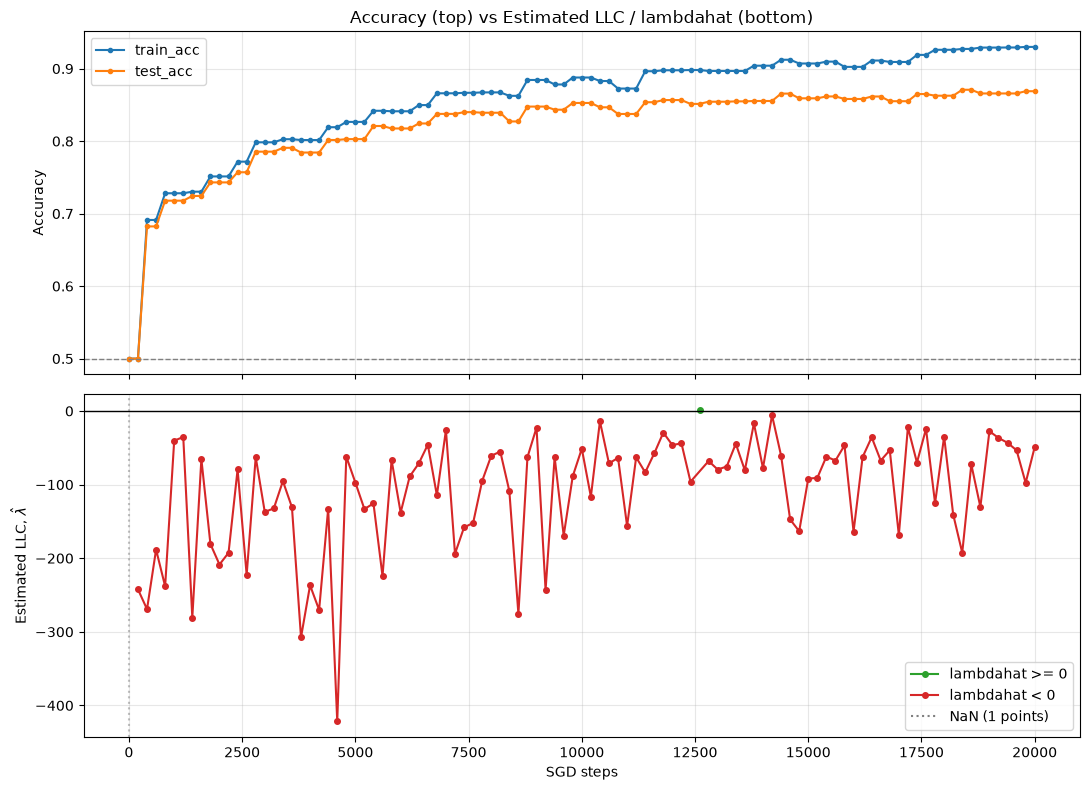

符号が変化するstep(の直後):
[12600, 12800]


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# --- 上段: 精度カーブ ---
ax0 = axes[0]
ax0.plot(merged["step"], merged["train_acc"], label="train_acc", marker="o", markersize=3)
ax0.plot(merged["step"], merged["test_acc"], label="test_acc", marker="o", markersize=3)
ax0.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax0.set_ylabel("Accuracy")
ax0.set_title("Accuracy (top) vs Estimated LLC / lambdahat (bottom)")
ax0.legend()
ax0.grid(alpha=0.3)

# --- 下段: λ (符号で色分け、NaNは別マーカー) ---
ax1 = axes[1]
valid = merged.dropna(subset=["lambdahat"])
pos = valid[valid["lambdahat"] >= 0]
neg = valid[valid["lambdahat"] < 0]
nan_steps = merged[merged["lambdahat"].isna()]["step"]

ax1.plot(pos["step"], pos["lambdahat"], "o-", color="tab:green", markersize=4, label="lambdahat >= 0")
ax1.plot(neg["step"], neg["lambdahat"], "o-", color="tab:red", markersize=4, label="lambdahat < 0")
for s in nan_steps:
    ax1.axvline(s, color="gray", linestyle=":", alpha=0.5)
if len(nan_steps) > 0:
    ax1.plot([], [], color="gray", linestyle=":", label=f"NaN ({len(nan_steps)} points)")

ax1.axhline(0, color="black", linewidth=1)
ax1.set_xlabel("SGD steps")
ax1.set_ylabel(r"Estimated LLC, $\hat{\lambda}$")
ax1.legend()
ax1.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("nakkiran_binary_llc_vs_accuracy.pdf", bbox_inches="tight")
plt.show()

# --- 符号が反転する境界を機械的に検出 ---
valid_sorted = valid.sort_values("step").reset_index(drop=True)
sign = np.sign(valid_sorted["lambdahat"])
sign_changes = valid_sorted["step"][sign.diff().fillna(0) != 0]
print("符号が変化するstep(の直後):")
print(sign_changes.tolist())

# 描画

In [ ]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

llc_dir = Path("llc_results")
gpu_files = sorted(llc_dir.glob("nakkiran_binary_llc_uniform_gpu*.json"))
print(f"Found {len(gpu_files)} files: {[f.name for f in gpu_files]}")

all_results = []
sgld_config_check = None
for f in gpu_files:
    with open(f) as fh:
        data = json.load(fh)
    if sgld_config_check is None:
        sgld_config_check = data["sgld_config"]
    elif data["sgld_config"] != sgld_config_check:
        print(f"WARNING: {f.name} の sgld_config が他と異なります: {data['sgld_config']}")
    all_results.extend(data["results"])

llc_df = pd.DataFrame(all_results).sort_values("step").reset_index(drop=True)
llc_df = llc_df.drop_duplicates(subset="step", keep="last")

n_nan = llc_df["lambdahat"].isna().sum()
n_negative = (llc_df["lambdahat"] < 0).sum()
n_total = len(llc_df)
print(f"Total checkpoints: {n_total}")
print(f"  NaN: {n_nan} ({n_nan/n_total:.1%})")
print(f"  Negative (non-NaN): {n_negative} ({n_negative/n_total:.1%})")
print(f"  Positive: {n_total - n_nan - n_negative}")
print(f"SGLD config used: {sgld_config_check}")

Found 4 files: ['nakkiran_binary_llc_uniform_gpu0.json', 'nakkiran_binary_llc_uniform_gpu1.json', 'nakkiran_binary_llc_uniform_gpu2.json', 'nakkiran_binary_llc_uniform_gpu3.json']
Total checkpoints: 101
  NaN: 1 (1.0%)
  Negative (non-NaN): 99 (98.0%)
  Positive: 1
SGLD config used: {'epsilon': 2e-08, 'gamma': 1.0, 'num_steps': 1000, 'batch_size': 2048}


In [ ]:
results_base = Path("results/nakkiran_binary_training")
run_dirs = [p for p in results_base.iterdir() if p.is_dir() and p.name.isdigit()]
latest_run = max(run_dirs, key=lambda p: int(p.name))
print(f"Loading training log: {latest_run}")

with open(latest_run / "info.json") as f:
    info = json.load(f)
acc_df = pd.DataFrame(info).sort_values("step").reset_index(drop=True)

merged = pd.merge_asof(
    llc_df.sort_values("step"),
    acc_df.sort_values("step"),
    on="step",
    direction="nearest",
)

Loading training log: results/nakkiran_binary_training/1


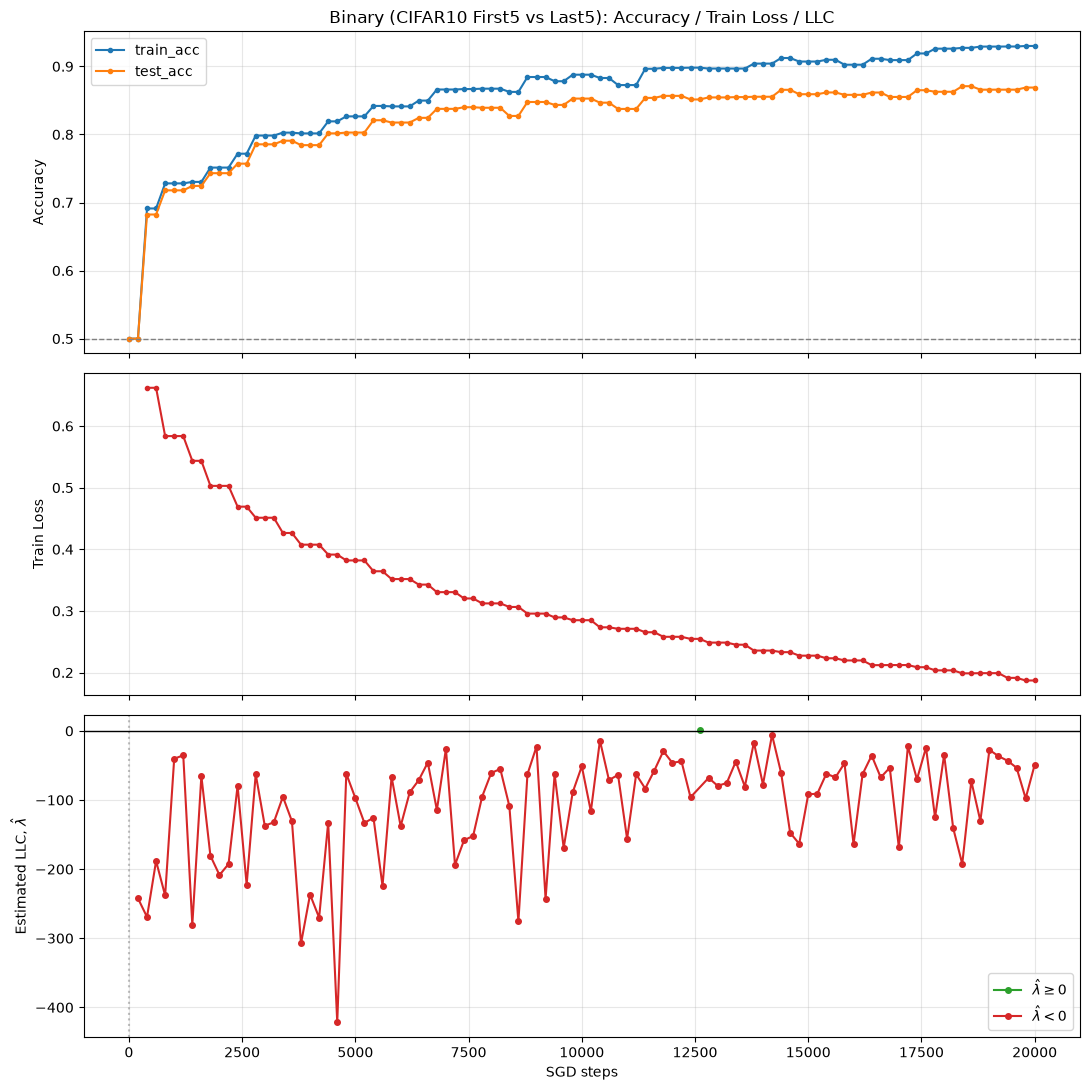

符号が変化するstep:
[12600, 12800]


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

# --- 1段目: 精度カーブ ---
ax0 = axes[0]
ax0.plot(merged["step"], merged["train_acc"], label="train_acc", marker="o", markersize=3)
ax0.plot(merged["step"], merged["test_acc"], label="test_acc", marker="o", markersize=3)
ax0.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax0.set_ylabel("Accuracy")
ax0.set_title("Binary (CIFAR10 First5 vs Last5): Accuracy / Train Loss / LLC")
ax0.legend()
ax0.grid(alpha=0.3)

# --- 2段目: train_loss (線形軸) ---
ax1 = axes[1]
train_loss_valid = merged.dropna(subset=["train_loss"])
ax1.plot(train_loss_valid["step"], train_loss_valid["train_loss"],
          "o-", color="tab:red", markersize=3)
ax1.set_ylabel("Train Loss")
ax1.grid(alpha=0.3)

# --- 3段目: λ (符号で色分け) ---
ax2 = axes[2]
valid = merged.dropna(subset=["lambdahat"])
pos = valid[valid["lambdahat"] >= 0]
neg = valid[valid["lambdahat"] < 0]
nan_steps = merged[merged["lambdahat"].isna()]["step"]

ax2.plot(pos["step"], pos["lambdahat"], "o-", color="tab:green", markersize=4, label=r"$\hat{\lambda} \geq 0$")
ax2.plot(neg["step"], neg["lambdahat"], "o-", color="tab:red", markersize=4, label=r"$\hat{\lambda} < 0$")
for s in nan_steps:
    ax2.axvline(s, color="gray", linestyle=":", alpha=0.5)
ax2.axhline(0, color="black", linewidth=1)
ax2.set_xlabel("SGD steps")
ax2.set_ylabel(r"Estimated LLC, $\hat{\lambda}$")
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("nakkiran_binary_llc_full_diagnostic.pdf", bbox_inches="tight")
plt.show()

# --- 符号反転点の検出 ---
valid_sorted = valid.sort_values("step").reset_index(drop=True)
sign = np.sign(valid_sorted["lambdahat"])
sign_changes = valid_sorted["step"][sign.diff().fillna(0) != 0]
print("符号が変化するstep:")
print(sign_changes.tolist())

In [ ]:
print("=" * 60)
print("予備確認 サマリー")
print("=" * 60)
print(f"チェックポイント数: {n_total} (200ステップ間隔、均等抽出)")
print(f"SGLD設定: epsilon={sgld_config_check['epsilon']:.2e}, "
      f"gamma={sgld_config_check['gamma']}, "
      f"num_steps={sgld_config_check['num_steps']}, "
      f"batch_size={sgld_config_check['batch_size']}")
print(f"最終精度: train_acc={merged['train_acc'].iloc[-1]:.3f}, "
      f"test_acc={merged['test_acc'].iloc[-1]:.3f}")
print(f"lambdahat: 正={n_total-n_nan-n_negative}点, 負={n_negative}点, NaN={n_nan}点")
print(f"init_lossの隣接ステップ間変動(平均): {init_loss_diff.mean():.4f}")

予備確認 サマリー
チェックポイント数: 101 (200ステップ間隔、均等抽出)
SGLD設定: epsilon=2.00e-08, gamma=1.0, num_steps=1000, batch_size=2048
最終精度: train_acc=0.930, test_acc=0.869
lambdahat: 正=1点, 負=99点, NaN=1点
init_lossの隣接ステップ間変動(平均): 0.0200


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")

# ─── LLC結果読み込み関数 ───
def load_llc_results(name):
    with open(RESULTS_DIR / "llc_results" / f"{name}.json") as f:
        return json.load(f)

def compute_lambdahat(rec, n, burn_in_ratio=0.9):
    trace = np.array(rec["loss_trace"])
    init_loss = rec["init_loss"]
    itemp = 1 / np.log(n)
    burn_in = int(len(trace) * burn_in_ratio)
    valid = trace[burn_in:]
    valid = valid[~np.isnan(valid) & ~np.isinf(valid)]
    if len(valid) == 0:
        return np.nan
    return (np.mean(valid) - init_loss) * n * itemp

# ─── Acc/Loss結果読み込み関数 ───
def load_eval_results(name):
    with open(RESULTS_DIR / "eval_results" / f"{name}.json") as f:
        return json.load(f)

# ─── CIFAR10基準(train) ───
with open(RESULTS_DIR / "dsb_eval_results.json") as f:
    cifar_eval = json.load(f)
cifar_steps     = [r["step"] for r in cifar_eval]
cifar_train_acc = [r["train_acc"] for r in cifar_eval]

# ─── 手法ごとのAcc/LLCをまとめて読み込む ───
method_files = {
    "conrad": ("conrad_full", "conrad_llc_full"),
    "gaussian": ("gaussian_full", "gaussian_llc_full"),
    "ics": ("ics_full", "ics_llc_full"),
    "truncated_normal": ("truncated_normal_full", "truncated_normal_llc_full"),
}

colors = {
    "conrad": "darkred",
    "gaussian": "darkorange",
    "ics": "darkgreen",
    "truncated_normal": "darkviolet",
    "cifar10_train": "steelblue",
}

acc_curves = {}
llc_curves = {}

for name, (eval_name, llc_name) in method_files.items():
    eval_data = load_eval_results(eval_name)
    acc_steps = [r["step"] for r in eval_data["results"]]
    acc_vals  = [r["accuracy"] for r in eval_data["results"]]
    acc_curves[name] = (np.array(acc_steps), np.array(acc_vals))

    llc_data = load_llc_results(llc_name)
    n = llc_data["n_llc_samples_actual"]
    llc_steps = [r["step"] for r in llc_data["results"]]
    llc_vals  = [compute_lambdahat(r, n, burn_in_ratio=0.9) for r in llc_data["results"]]
    llc_curves[name] = (np.array(llc_steps), np.array(llc_vals))

# CIFAR10のLLCも追加
cifar_llc_data = load_llc_results("cifar10_train_llc_full")
n_cifar = cifar_llc_data["n_llc_samples_actual"]
cifar_llc_steps = [r["step"] for r in cifar_llc_data["results"]]
cifar_llc_vals  = [compute_lambdahat(r, n_cifar, burn_in_ratio=0.9) for r in cifar_llc_data["results"]]
llc_curves["cifar10_train"] = (np.array(cifar_llc_steps), np.array(cifar_llc_vals))

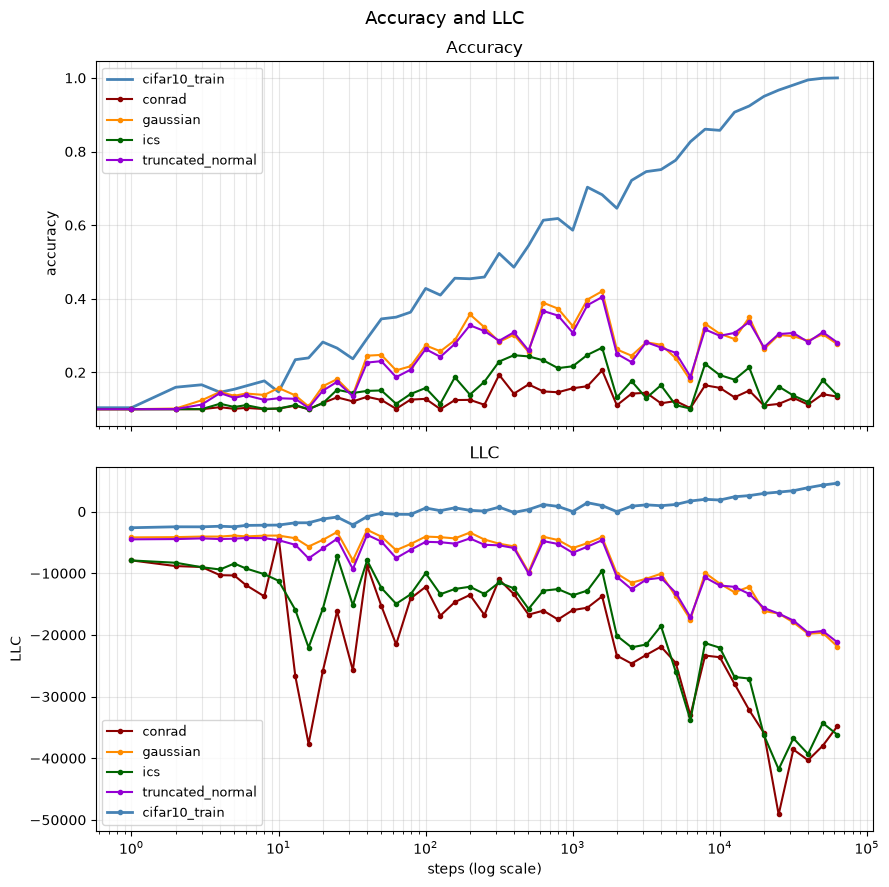

In [ ]:
STEP_LIMIT = 200000  # 序盤に絞りたい場合。Noneなら全範囲

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

# ── 上段: Accuracy ──
ax = axes[0]
ax.plot(cifar_steps, cifar_train_acc, color=colors["cifar10_train"],
        linewidth=2, label="cifar10_train")
for name, (steps, accs) in acc_curves.items():
    mask = (steps <= STEP_LIMIT) if STEP_LIMIT is not None else np.ones_like(steps, dtype=bool)
    ax.plot(steps[mask], accs[mask], marker="o", markersize=3,
            color=colors[name], label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# ── 下段: LLC ──
ax = axes[1]
for name, (steps, lambdahats) in llc_curves.items():
    mask = ~np.isnan(lambdahats)
    if STEP_LIMIT is not None:
        mask &= (steps <= STEP_LIMIT)
    mask &= (steps >= 1)
    ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=3,
            color=colors[name], label=name,
            linewidth=2 if name == "cifar10_train" else 1.5)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
#ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_ylabel(r"LLC")
ax.set_title("LLC")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

fig.suptitle("Accuracy and LLC", fontsize=13)
fig.tight_layout()

suffix = f"_upto{STEP_LIMIT}" if STEP_LIMIT is not None else "_full"
plt.savefig(RESULTS_DIR / f"deletion_acc_llc_aligned{suffix}.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")

# ─── LLC結果読み込み関数 ───
def load_llc_results(name):
    with open(RESULTS_DIR / "llc_results" / f"{name}.json") as f:
        return json.load(f)

def compute_lambdahat(rec, n, burn_in_ratio=0.9):
    trace = np.array(rec["loss_trace"])
    init_loss = rec["init_loss"]
    itemp = 1 / np.log(n)
    burn_in = int(len(trace) * burn_in_ratio)
    valid = trace[burn_in:]
    valid = valid[~np.isnan(valid) & ~np.isinf(valid)]
    if len(valid) == 0:
        return np.nan
    return (np.mean(valid) - init_loss) * n * itemp

# ─── Acc/Loss結果読み込み関数 ───
def load_eval_results(name):
    with open(RESULTS_DIR / "eval_results" / f"{name}.json") as f:
        return json.load(f)

# ─── CIFAR10基準(train) ───
with open(RESULTS_DIR / "dsb_eval_results.json") as f:
    cifar_eval = json.load(f)
cifar_steps     = [r["step"] for r in cifar_eval]
cifar_train_acc = [r["train_acc"] for r in cifar_eval]

# ─── Grafting手法ごとのAcc/LLCをまとめて読み込む ───
method_files = {
    "bounded_shift": ("bounded_shift_full", "bounded_shift_llc_full"),
    "cqn": ("cqn_full", "cqn_llc_full"),
    "gaussian_ot": ("gaussian_ot_full", "gaussian_ot_llc_full"),
}

colors = {
    "bounded_shift": "darkred",
    "cqn": "darkorange",
    "gaussian_ot": "darkviolet",
    "cifar10_train": "steelblue",
}

acc_curves = {}
llc_curves = {}

for name, (eval_name, llc_name) in method_files.items():
    eval_data = load_eval_results(eval_name)
    acc_steps = [r["step"] for r in eval_data["results"]]
    acc_vals  = [r["accuracy"] for r in eval_data["results"]]
    acc_curves[name] = (np.array(acc_steps), np.array(acc_vals))

    llc_data = load_llc_results(llc_name)
    n = llc_data["n_llc_samples_actual"]
    llc_steps = [r["step"] for r in llc_data["results"]]
    llc_vals  = [compute_lambdahat(r, n, burn_in_ratio=0.9) for r in llc_data["results"]]
    llc_curves[name] = (np.array(llc_steps), np.array(llc_vals))

# CIFAR10のLLCも追加
cifar_llc_data = load_llc_results("cifar10_train_llc_full")
n_cifar = cifar_llc_data["n_llc_samples_actual"]
cifar_llc_steps = [r["step"] for r in cifar_llc_data["results"]]
cifar_llc_vals  = [compute_lambdahat(r, n_cifar, burn_in_ratio=0.9) for r in cifar_llc_data["results"]]
llc_curves["cifar10_train"] = (np.array(cifar_llc_steps), np.array(cifar_llc_vals))

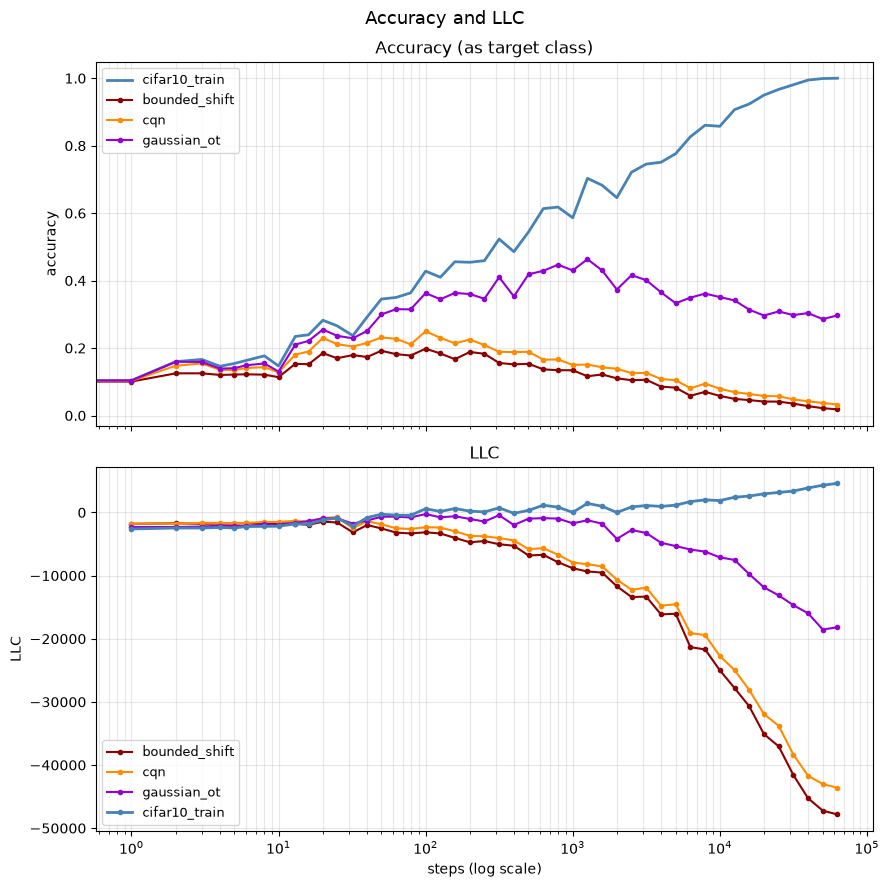

In [ ]:
STEP_LIMIT = 200000  # 序盤に絞りたい場合。Noneなら全範囲

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

# ── 上段: Accuracy ──
ax = axes[0]
ax.plot(cifar_steps, cifar_train_acc, color=colors["cifar10_train"],
        linewidth=2, label="cifar10_train")
for name, (steps, accs) in acc_curves.items():
    mask = (steps <= STEP_LIMIT) if STEP_LIMIT is not None else np.ones_like(steps, dtype=bool)
    ax.plot(steps[mask], accs[mask], marker="o", markersize=3,
            color=colors[name], label=name)
ax.set_xscale("log")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy (as target class)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# ── 下段: LLC ──
ax = axes[1]
for name, (steps, lambdahats) in llc_curves.items():
    mask = ~np.isnan(lambdahats)
    if STEP_LIMIT is not None:
        mask &= (steps <= STEP_LIMIT)
    mask &= (steps >= 1)
    ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=3,
            color=colors[name], label=name,
            linewidth=2 if name == "cifar10_train" else 1.5)
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC")
ax.set_title("LLC")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

fig.suptitle("Accuracy and LLC", fontsize=13)
fig.tight_layout()

suffix = f"_upto{STEP_LIMIT}" if STEP_LIMIT is not None else "_full"
plt.savefig(RESULTS_DIR / f"grafting_acc_llc_aligned{suffix}.pdf", bbox_inches="tight")
plt.show()

In [ ]:
with open("llc_results/nakkiran_binary_batch_loss.json") as f:
    batch_data = json.load(f)
batch_df = pd.DataFrame(batch_data["results"]).sort_values("step").reset_index(drop=True)

merged2 = pd.merge(merged, batch_df, on="step", how="left")
merged2.head()

,step,init_loss,mean_loss_post_burnin,lambdahat,test_acc,train_acc,train_loss,batch_loss,batch_acc
0,0,0.693147,NaN,NaN,0.5000,0.50000,NaN,0.693147,0.437500
1,200,0.680503,0.628074,-242.283407,0.5000,0.50000,NaN,0.695961,0.609375
2,400,0.644334,0.586072,-269.237453,0.6824,0.69128,0.662065,0.668762,0.570312
3,600,0.610431,0.569687,-188.282583,0.6824,0.69128,0.662065,0.685358,0.640625
4,800,0.618739,0.567207,-238.138899,0.7179,0.72812,0.583704,0.652908,0.570312


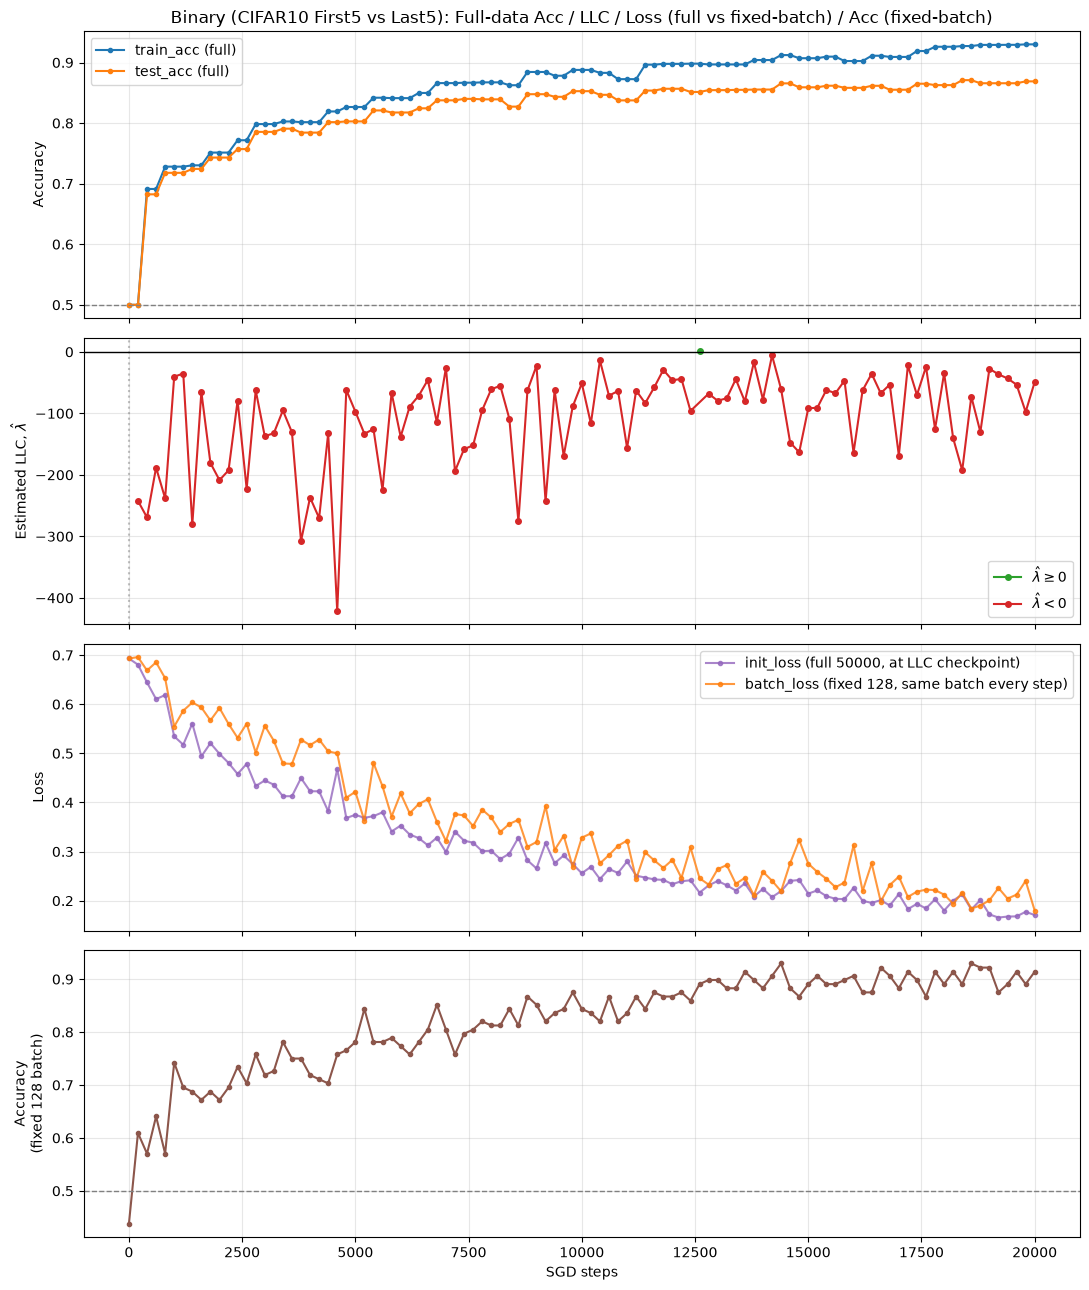

batch_loss(固定128枚)の隣接ステップ間変動: 平均=0.0337, 最大=0.1177
init_loss(全50000枚)の隣接ステップ間変動:   平均=0.0200, 最大=0.0997


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(11, 13), sharex=True)

# --- 1段目: 訓練全体の精度カーブ ---
ax0 = axes[0]
ax0.plot(merged2["step"], merged2["train_acc"], label="train_acc (full)", marker="o", markersize=3)
ax0.plot(merged2["step"], merged2["test_acc"], label="test_acc (full)", marker="o", markersize=3)
ax0.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax0.set_ylabel("Accuracy")
ax0.set_title("Binary (CIFAR10 First5 vs Last5): Full-data Acc / LLC / Loss (full vs fixed-batch) / Acc (fixed-batch)")
ax0.legend()
ax0.grid(alpha=0.3)

# --- 2段目: λ (符号で色分け) ---
ax1 = axes[1]
valid = merged2.dropna(subset=["lambdahat"])
pos = valid[valid["lambdahat"] >= 0]
neg = valid[valid["lambdahat"] < 0]
nan_steps = merged2[merged2["lambdahat"].isna()]["step"]

ax1.plot(pos["step"], pos["lambdahat"], "o-", color="tab:green", markersize=4, label=r"$\hat{\lambda} \geq 0$")
ax1.plot(neg["step"], neg["lambdahat"], "o-", color="tab:red", markersize=4, label=r"$\hat{\lambda} < 0$")
for s in nan_steps:
    ax1.axvline(s, color="gray", linestyle=":", alpha=0.5)
ax1.axhline(0, color="black", linewidth=1)
ax1.set_ylabel(r"Estimated LLC, $\hat{\lambda}$")
ax1.legend()
ax1.grid(alpha=0.3)

# --- 3段目: init_loss (全50000枚) vs batch_loss (固定128枚) ---
ax2 = axes[2]
ax2.plot(merged2["step"], merged2["init_loss"], "o-", color="tab:purple", markersize=3,
          alpha=0.8, label="init_loss (full 50000, at LLC checkpoint)")
ax2.plot(merged2["step"], merged2["batch_loss"], "o-", color="tab:orange", markersize=3,
          alpha=0.8, label="batch_loss (fixed 128, same batch every step)")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(alpha=0.3)

# --- 4段目: batch_acc (固定128枚での正解率) ---
ax3 = axes[3]
ax3.plot(merged2["step"], merged2["batch_acc"], "o-", color="tab:brown", markersize=3)
ax3.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax3.set_xlabel("SGD steps")
ax3.set_ylabel("Accuracy\n(fixed 128 batch)")
ax3.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("nakkiran_binary_llc_full_diagnostic_v2.pdf", bbox_inches="tight")
plt.show()

# --- 振動幅の定量比較 ---
batch_loss_diff = merged2["batch_loss"].diff().abs()
init_loss_diff = merged2["init_loss"].diff().abs()
print(f"batch_loss(固定128枚)の隣接ステップ間変動: 平均={batch_loss_diff.mean():.4f}, 最大={batch_loss_diff.max():.4f}")
print(f"init_loss(全50000枚)の隣接ステップ間変動:   平均={init_loss_diff.mean():.4f}, 最大={init_loss_diff.max():.4f}")

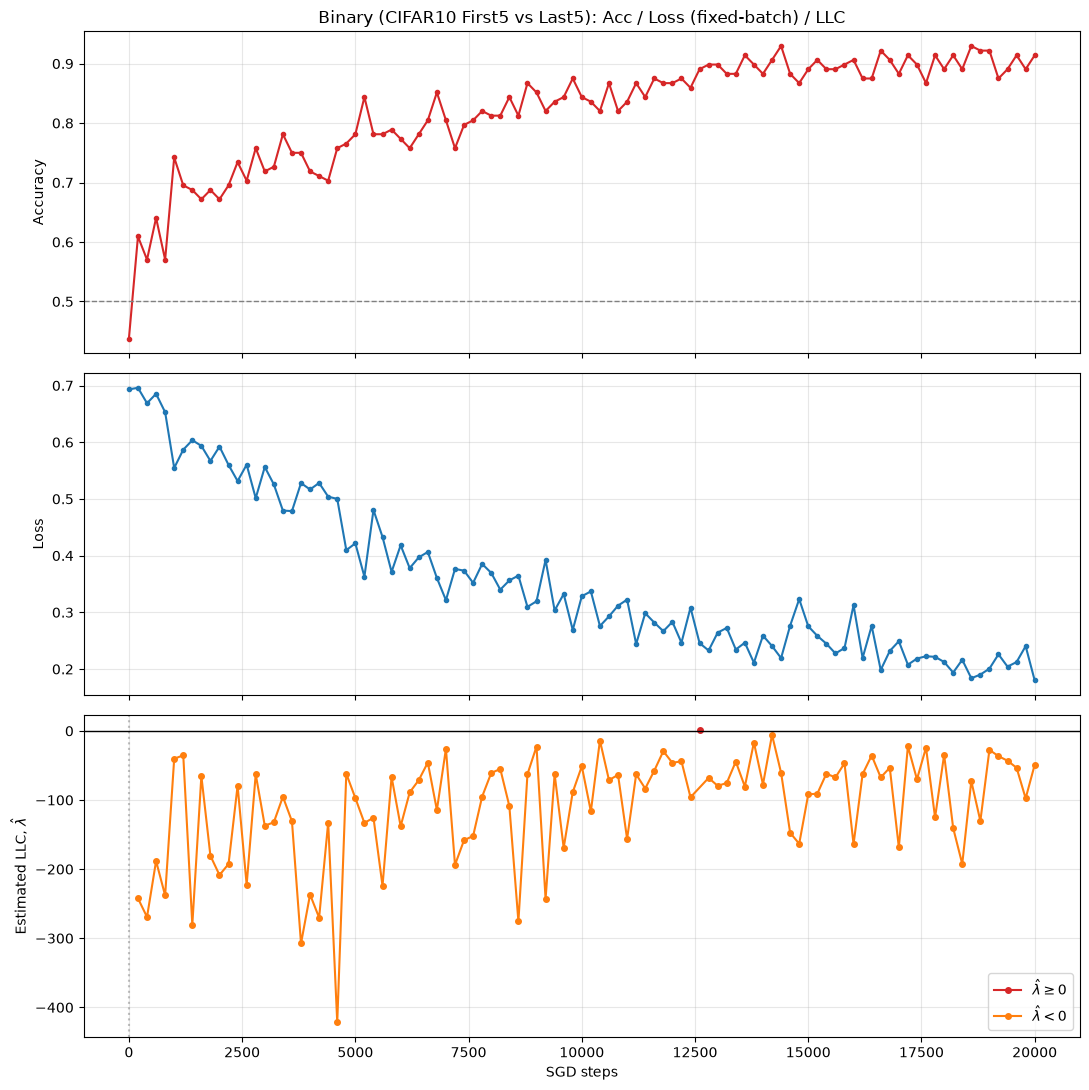

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

# --- 1段目: Accuracy (固定128バッチ) ---
ax0 = axes[0]
ax0.plot(merged2["step"], merged2["batch_acc"], "o-", color="tab:red", markersize=3)
ax0.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax0.set_ylabel("Accuracy")
ax0.set_title("Binary (CIFAR10 First5 vs Last5): Acc / Loss (fixed-batch) / LLC")
ax0.grid(alpha=0.3)

# --- 2段目: Loss (固定128バッチ) ---
ax1 = axes[1]
ax1.plot(merged2["step"], merged2["batch_loss"], "o-", color="tab:blue", markersize=3)
ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3)

# --- 3段目: λ (符号で色分け) ---
ax2 = axes[2]
valid = merged2.dropna(subset=["lambdahat"])
pos = valid[valid["lambdahat"] >= 0]
neg = valid[valid["lambdahat"] < 0]
nan_steps = merged2[merged2["lambdahat"].isna()]["step"]

ax2.plot(pos["step"], pos["lambdahat"], "o-", color="tab:red", markersize=4, label=r"$\hat{\lambda} \geq 0$")
ax2.plot(neg["step"], neg["lambdahat"], "o-", color="tab:orange", markersize=4, label=r"$\hat{\lambda} < 0$")
for s in nan_steps:
    ax2.axvline(s, color="gray", linestyle=":", alpha=0.5)
ax2.axhline(0, color="black", linewidth=1)
ax2.set_xlabel("SGD steps")
ax2.set_ylabel(r"Estimated LLC, $\hat{\lambda}$")
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("nakkiran_binary_llc_fixedbatch_3panel.pdf", bbox_inches="tight")
plt.show()

学習し終わったネットの複雑性を
モデルの大きさを変えてみる

指標としての振る舞いを理解してから
→

線形


入力空間→→をもっと


LLCと何かを回帰する
なんらかの性質を見る


loglog 

